# Heart Disease Classification

## Project Overview

The goal of this project is to build machine learning models capable of predicting whether a patient has heart disease based on demographic, clinical, and diagnostic measurements collected during cardiovascular examinations.

Two fundamentally different classification approaches will be explored and compared:

* Logistic Regression
* K-Nearest Neighbors (KNN)

The purpose of this project is not only to build accurate classifiers, but also to understand how different machine learning algorithms approach the same prediction problem and why they may produce different results.

For this project, the target variable will contain two classes:

* 0 = No Heart Disease
* 1 = Heart Disease

## Why Compare Logistic Regression and KNN?

Although both models solve the same classification task, they do so in very different ways.

* Logistic Regression learns a mathematical relationship between features and the target.
* KNN makes predictions by finding the most similar observations in the training data.

Comparing these models on the same dataset provides an opportunity to understand:

* Model-based learning vs distance-based learning
* The impact of feature scaling
* Hyperparameter tuning through K selection
* Classification model evaluation
* How different algorithms behave on the same problem

## Project Workflow

1. Load and inspect the dataset
2. Visualize the data and perform exploratory data analysis (EDA)
3. Clean and preprocess the data
4. Split the dataset into training and testing sets
5. Apply preprocessing to training and testing data
6. Train Logistic Regression and KNN models
7. Evaluate and compare model performance
8. Generate predictions on unseen samples
9. Analyze results and draw conclusions

## Learning Goals

This project is designed to strengthen practical machine learning skills by focusing on:

* Understanding how the K-Nearest Neighbors algorithm works
* Reinforcing Logistic Regression concepts through comparison
* Comparing distance-based learning with model-based learning
* Understanding the importance of feature scaling and its impact on KNN performance
* Exploring the effect of different K values on model behavior
* Practicing classification model evaluation using accuracy, precision, recall, F1-score, and confusion matrices
* Learning how to compare machine learning models fairly on the same dataset
* Building intuition about why different algorithms produce different results
* Developing a structured workflow for EDA, preprocessing, model training, and evaluation

## Dataset Information

The dataset contains 920 patient records collected from multiple international cardiovascular research centers and hospitals.

Features include patient demographics, chest pain characteristics, blood pressure measurements, cholesterol levels, electrocardiographic results, exercise test outcomes, and other clinical indicators commonly used in the diagnosis of heart disease.

The original target variable contains five classes:

* 0 = No Heart Disease
* 1 = Heart Disease (Level 1)
* 2 = Heart Disease (Level 2)
* 3 = Heart Disease (Level 3)
* 4 = Heart Disease (Level 4)

For this project, the target will be converted into a binary classification problem:

* 0 = No Heart Disease
* 1 = Heart Disease

## Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Jupyter Notebook


## 1. Load Dataset

In [624]:
import pandas as pd

In [625]:
df = pd.read_csv("heart_disease_uci.csv")
df.columns = df.columns.str.strip() # Strip leading and trailing spaces from all column names

In [626]:
df = df.rename(columns={
    "cp": "Chest Pain Type",
    "trestbps": "Resting Blood Pressure",
    "chol": "Cholesterol",
    "thalch": "Max Heart Rate",
    "exang": "Exercise Angina",
    "num": "Heart Disease Status"
})

## 2. Show Dataset Details

In [627]:
df.head()

,id,age,sex,dataset,Chest Pain Type,Resting Blood Pressure,Cholesterol,fbs,restecg,Max Heart Rate,Exercise Angina,oldpeak,slope,ca,thal,Heart Disease Status
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [628]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      920 non-null    int64  
 1   age                     920 non-null    int64  
 2   sex                     920 non-null    str    
 3   dataset                 920 non-null    str    
 4   Chest Pain Type         920 non-null    str    
 5   Resting Blood Pressure  861 non-null    float64
 6   Cholesterol             890 non-null    float64
 7   fbs                     830 non-null    object 
 8   restecg                 918 non-null    str    
 9   Max Heart Rate          865 non-null    float64
 10  Exercise Angina         865 non-null    object 
 11  oldpeak                 858 non-null    float64
 12  slope                   611 non-null    str    
 13  ca                      309 non-null    float64
 14  thal                    434 non-null    str    
 15  

In [629]:
df.describe()

,id,age,Resting Blood Pressure,Cholesterol,Max Heart Rate,oldpeak,ca,Heart Disease Status
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Reference Guide for Dataset Features

**Age**
- Adult: 18–64 years
- Older Adult: 65+ years

**Resting Blood Pressure (`trestbps`)**
- Normal: Below 120 mm Hg
- Elevated: 120–129 mm Hg
- High: 130+ mm Hg

**Serum Cholesterol (`chol`)**
- Desirable: Below 200 mg/dL
- Borderline High: 200–239 mg/dL
- High: 240+ mg/dL

**Fasting Blood Sugar (`fbs`)**
- 0 = Fasting blood sugar ≤ 120 mg/dL
- 1 = Fasting blood sugar > 120 mg/dL

**Maximum Heart Rate (`thalch`)**
- Higher values generally indicate better exercise response.
- Lower values may be associated with reduced cardiovascular fitness or cardiac issues.

**Exercise-Induced Angina (`exang`)**
- 0 = No
- 1 = Yes

**Oldpeak**
- ST depression induced by exercise relative to rest.
- Higher values may indicate greater abnormality during exercise testing.

**Number of Major Vessels (`ca`)**
- Ranges from 0 to 3 in the original description.
- Higher values may indicate more vessels affected.

**Target (`num`)**
- 0 = No heart disease
- 1–4 = Presence/severity of heart disease

## 3. Data Visualization & Exploratory Data Analysis (EDA)

In [630]:
import matplotlib.pyplot as plt
import seaborn as sns

In [631]:
for col in df.columns:
    print(col)

id
age
sex
dataset
Chest Pain Type
Resting Blood Pressure
Cholesterol
fbs
restecg
Max Heart Rate
Exercise Angina
oldpeak
slope
ca
thal
Heart Disease Status


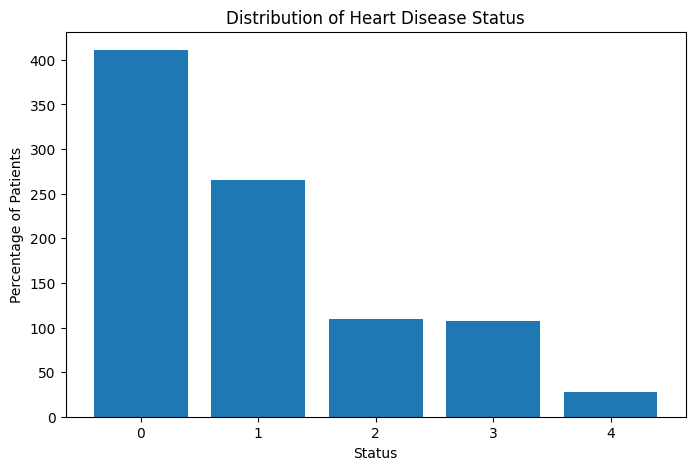

In [632]:
status_counts = df["Heart Disease Status"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values)
# status_counts.index
# Index([0,1,2,3,4])

# status_counts.values
# array([411 265 109 107  28])

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Status")
plt.ylabel("Percentage of Patients")
plt.show()

### Observations

- Most patients are either labeled as having no heart disease or a lower disease severity level.
- Higher severity classes are much less frequent.
- The original target column is multi-class, where 0 means no heart disease and values 1–4 represent different levels of heart disease presence/severity.

### Potential Actions

- Convert the target into a binary classification problem:
  - 0 = No Heart Disease
  - 1 = Heart Disease
- Use the binary target for Logistic Regression and KNN classification.

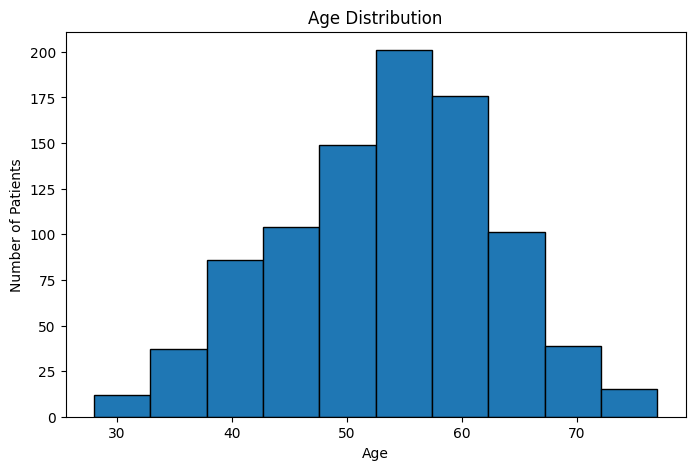

In [633]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")   
plt.ylabel("Number of Patients")

plt.show()

### Observations

- The age distribution is approximately bell-shaped and centered around middle-aged adults.
- Most patients are between 45 and 65 years old.
- Very young and very old patients are less common in the dataset.
- The distribution appears realistic for a cardiovascular disease study, as middle-aged and older adults are more likely to undergo cardiac evaluation.

### Potential Actions

- Investigate whether heart disease prevalence increases with age.
- Compare age distributions between patients with and without heart disease.
- Retain age as an important predictive feature for model training.

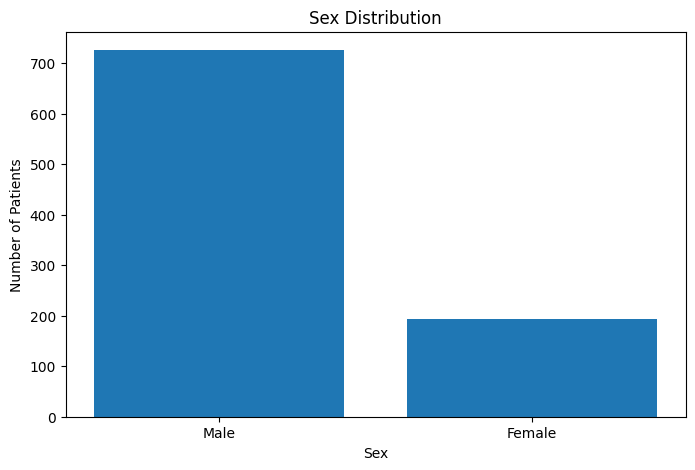

In [634]:
sex_counts = df["sex"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(sex_counts.index, sex_counts.values)

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

### Observations
- The dataset contains substantially more male patients than female patients.
- Male patients represent the majority of the study population.
- Female patients are underrepresented compared to males.
### Potential Actions
- Investigate whether heart disease prevalence differs between males and females.
- Check whether sex is an important predictor of heart disease.
- Keep this imbalance in mind when interpreting model results and dataset conclusions.

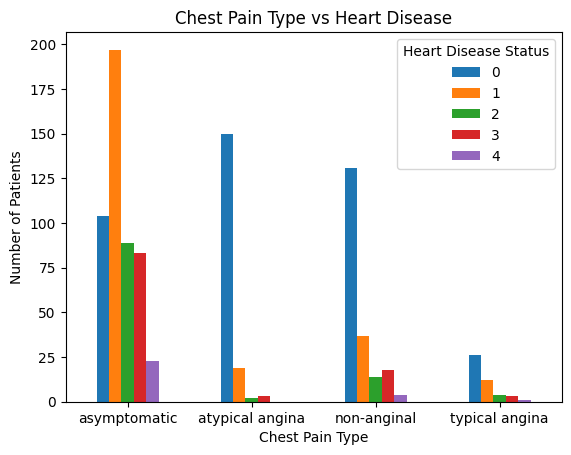

In [635]:
cp_status = pd.crosstab(
    df["Chest Pain Type"],
    df["Heart Disease Status"]
)
cp_status.plot(kind="bar", rot=0)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.show()

### Observations

- Chest pain type appears strongly associated with heart disease severity.
- Asymptomatic patients exhibit the highest number of positive heart disease cases.
- Atypical angina and non-anginal chest pain are more frequently associated with patients who do not have heart disease.
- Chest pain type is likely to be an important predictive feature during model training.

### Potential Actions

- Retain chest pain type as a feature.
- Examine the relationship again after converting the target to binary classes.
- Compare feature importance and model performance to determine how predictive chest pain type is.

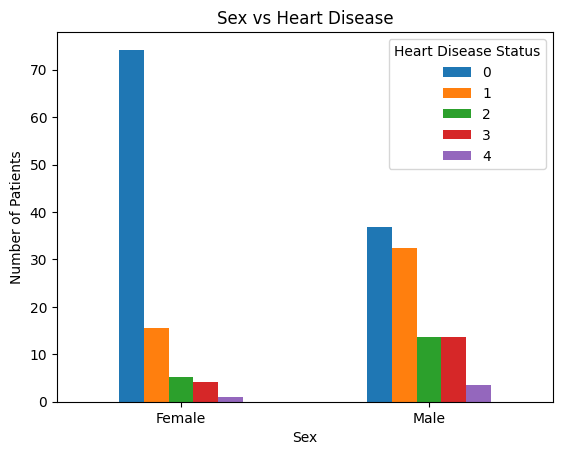

In [636]:
cp_status = pd.crosstab(
    df["sex"],
    df["Heart Disease Status"],
    normalize="index"
) * 100
cp_status.plot(kind="bar", rot=0)
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.show()

### Observations

- Male patients represent the majority of the dataset.
- Both male and female patients appear across all heart disease severity levels.
- Female patients are more frequently represented in the no-disease category within this subset.
- Male patients appear to have a higher number of positive heart disease cases, although the difference should be evaluated using percentages rather than raw counts.
- Sex may contain predictive information and should be investigated further during preprocessing and model evaluation.

### Potential Actions

- Compare heart disease rates between males and females using percentages.
- Retain sex as a predictive feature.
- Examine whether sex contributes meaningfully to model performance.
- Investigate possible interactions between sex and other clinical features.

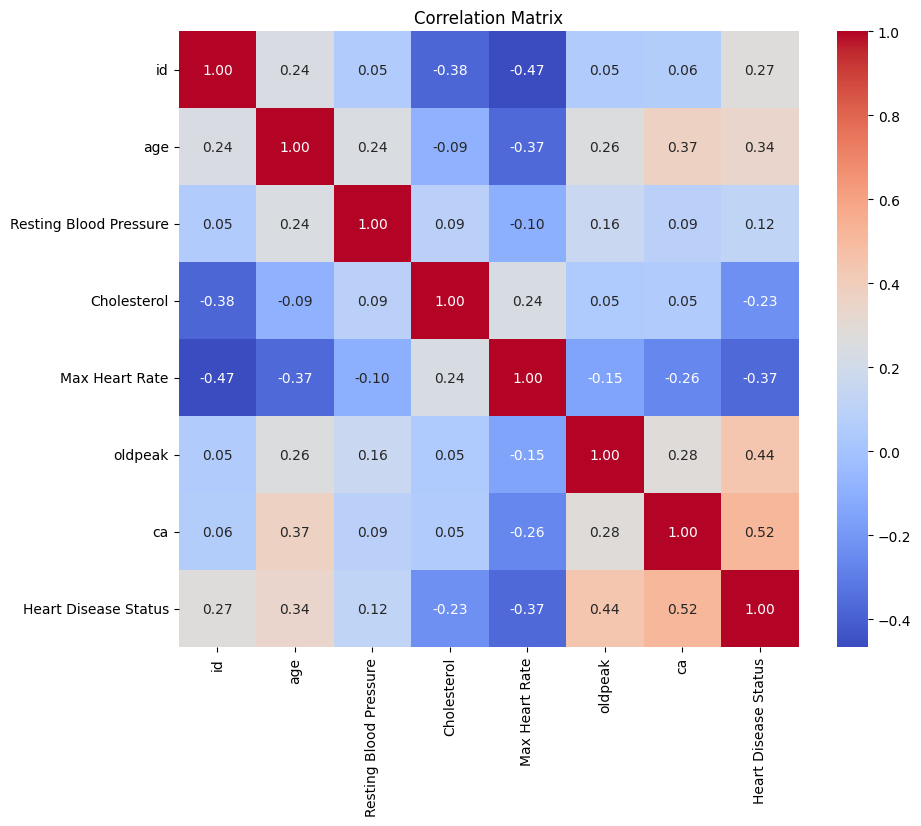

In [637]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Observations

- No single feature shows an extremely strong correlation with heart disease status.
- The strongest positive correlations with heart disease status are:
  - Number of major vessels (`ca`) = 0.52
  - Oldpeak = 0.44
  - Age = 0.34
- Maximum Heart Rate shows a moderate negative correlation (-0.37), suggesting patients with more severe heart disease tend to achieve lower maximum heart rates.
- Resting Blood Pressure and Cholesterol show relatively weak correlations with heart disease status.
- The dataset appears realistic, as heart disease is associated with multiple moderate predictors rather than a single dominant feature.

### Potential Actions

- Retain all clinically relevant features for model training.
- Investigate categorical features after encoding, as important relationships may not appear in this correlation matrix.
- Use machine learning models to capture the combined effect of multiple features rather than relying on individual correlations.

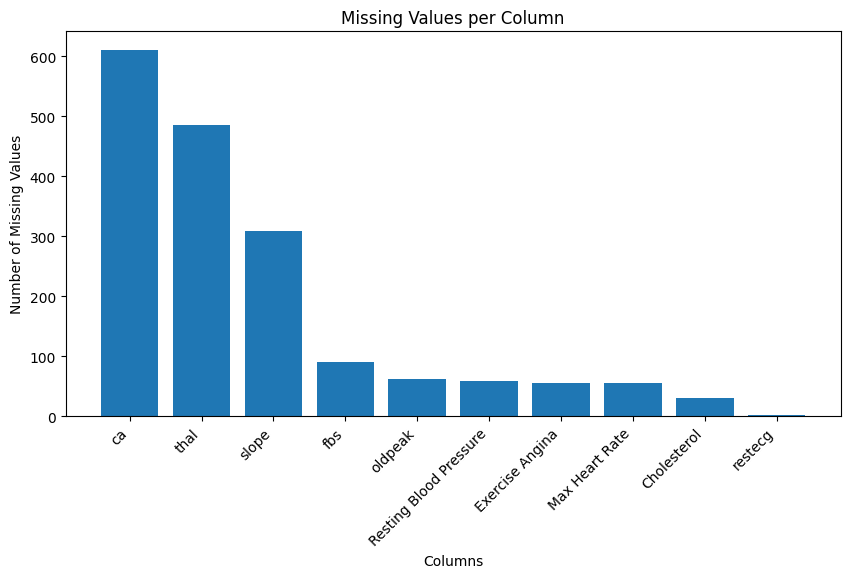

In [638]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))
plt.bar(missing_values.index, missing_values.values)

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")

plt.show()

### Observations

- Some columns contain missing values.
- The missing values are concentrated in specific features rather than spread equally across the dataset.
- These missing values must be handled before model training.

### Potential Actions

- Drop columns with excessive missing values if they are not reliable.
- Impute missing numerical values using the median.
- Impute missing categorical values using the most frequent category.
- Apply imputation only after splitting the data to avoid data leakage.

## 4. Data Cleaning & Preprocessing

In [639]:
df = df.drop(columns=["id", "dataset"])

### Dropping Unnecessary Columns

The `id` column is a unique patient identifier and does not contain information useful for predicting heart disease.

The `dataset` column identifies the hospital or research center from which the patient record originated. Since it does not represent a clinical characteristic of the patient, it will be removed from the analysis.

Both columns are therefore excluded from model training.

In [640]:
duplicates = df.duplicated().sum()
print("Shape before removing duplicates:", df.shape)
print("Number of duplicate rows:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Number of duplicate rows:", df.duplicated().sum())


Shape before removing duplicates: (920, 14)
Number of duplicate rows: 2
Shape after removing duplicates: (918, 14)
Number of duplicate rows: 0


In [641]:
df.isnull().sum().sort_values(ascending=False)

ca                        609
thal                      484
slope                     307
fbs                        90
oldpeak                    62
Resting Blood Pressure     59
Max Heart Rate             55
Exercise Angina            55
Cholesterol                29
restecg                     2
Chest Pain Type             0
sex                         0
age                         0
Heart Disease Status        0
dtype: int64

In [642]:
df[["ca", "thal", "slope"]].head(20)

,ca,thal,slope
0,0.0,fixed defect,downsloping
1,3.0,normal,flat
2,2.0,reversable defect,flat
3,0.0,normal,downsloping
4,0.0,normal,upsloping
5,0.0,normal,upsloping
6,2.0,normal,downsloping
7,0.0,normal,upsloping
8,1.0,reversable defect,flat
9,0.0,reversable defect,downsloping


In [643]:
df[["ca", "thal", "slope"]].info()

<class 'pandas.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ca      309 non-null    float64
 1   thal    434 non-null    str    
 2   slope   611 non-null    str    
dtypes: float64(1), str(2)
memory usage: 28.7 KB


In [644]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent)

ca                        66.339869
thal                      52.723312
slope                     33.442266
fbs                        9.803922
oldpeak                    6.753813
Resting Blood Pressure     6.427015
Max Heart Rate             5.991285
Exercise Angina            5.991285
Cholesterol                3.159041
restecg                    0.217865
Chest Pain Type            0.000000
sex                        0.000000
age                        0.000000
Heart Disease Status       0.000000
dtype: float64


In [645]:
df = df.drop(columns=["ca", "thal"])

### Handling Excessive Missing Values

The features `ca` and `thal` contained a substantial proportion of missing values:

- `ca`: 66.3% missing values
- `thal`: 52.7% missing values

Although both features may contain useful clinical information, more than half of their observations were unavailable. Imputing such a large percentage of missing values would introduce a significant amount of artificial information into the dataset and could negatively affect model reliability.

To preserve data quality and avoid excessive imputation, both features were removed from the analysis.

The remaining features were retained and will be handled through appropriate imputation techniques where necessary.

In [646]:
df.isnull().sum().sort_values(ascending=False)

slope                     307
fbs                        90
oldpeak                    62
Resting Blood Pressure     59
Exercise Angina            55
Max Heart Rate             55
Cholesterol                29
restecg                     2
Chest Pain Type             0
sex                         0
age                         0
Heart Disease Status        0
dtype: int64

### Handling Remaining Missing Values

After removing the `ca` and `thal` features, several columns still contained missing values.

To preserve as much data as possible, missing values were imputed according to the feature type:

- Numerical features were imputed using the median value.
- Categorical features were imputed using the most frequent category (mode).

This approach allows all observations to be retained while minimizing the impact of missing data on model training.

In [647]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [648]:
## Convert target to binary

df["Heart Disease Status"] = (df["Heart Disease Status"] > 0).astype(int)

df["Heart Disease Status"].value_counts()

Heart Disease Status
1    508
0    410
Name: count, dtype: int64

In [649]:
X = df.drop("Heart Disease Status", axis=1)
y = df["Heart Disease Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [650]:
numerical_features = [
    "age",
    "Resting Blood Pressure",
    "Cholesterol",
    "Max Heart Rate",
    "oldpeak"
]

categorical_features = [
    "sex",
    "Chest Pain Type",
    "fbs",
    "restecg",
    "Exercise Angina",
    "slope"
]

for column in numerical_features:
    median_value = X_train[column].median()
    X_train[column] = X_train[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)

for column in categorical_features:
    mode_value = X_train[column].mode()[0]
    X_train[column] = X_train[column].fillna(mode_value)
    X_test[column] = X_test[column].fillna(mode_value)

In [651]:
X_train.isnull().sum().sum()
X_test.isnull().sum().sum()

np.int64(0)

### Train-Test Split and Missing Value Handling

Before applying any preprocessing techniques, the dataset was divided into training and testing sets using an 80/20 split.

Missing values were intentionally handled **after** the train-test split to prevent data leakage.

If imputation is performed before splitting, statistical values such as the median or mode are calculated using information from the entire dataset, including observations that will later belong to the test set. This allows information from the test data to indirectly influence the training process.

To avoid this issue:

- Missing values in numerical features were imputed using the median calculated from the training set.
- Missing values in categorical features were imputed using the most frequent category (mode) calculated from the training set.
- The same values were then applied to both the training and testing sets.

After imputation, both the training and testing datasets contained no missing values and were ready for feature encoding and scaling.

### Encoding and Scaling

In [652]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [653]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [654]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (734, 21)
Testing shape: (184, 21)


### Feature Encoding and Scaling

Categorical features were transformed using One-Hot Encoding, converting each category into a binary feature representation.

Numerical features were standardized using StandardScaler to ensure that all variables operate on a comparable scale. This step is particularly important for K-Nearest Neighbors, which relies on distance calculations between observations.

After preprocessing:

- Training set shape: (734, 21)
- Testing set shape: (184, 21)

The data is now ready for model training.